# Import modules

In [1]:
import os
import sys
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
# from rdkit.Chem.Draw.MolDrawing import MolDrawing, DrawingOptions
# from rdkit.Chem.Draw import IPythonConsole
# IPythonConsole.ipython_useSVG = True

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.metrics import homogeneity_score

%matplotlib notebook

# import matplotlib
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Define function

In [2]:
def read_nonstd_ext_xyz(f):
    n_atoms = None

    R, z, E, F = [], [], [], []
    for i, line in enumerate(f):
        line = line.strip()
        if not n_atoms:
            n_atoms = int(line)
            # print('Number atoms per geometry: {:,}'.format(n_atoms))

        file_i, line_i = divmod(i, n_atoms + 2)

        if line_i == 1:
            try:
                e = float(line)
            except ValueError:
                pass
            else:
                E.append(e)

        cols = line.split()
        if line_i >= 2:
            R.append(list(map(float, cols[1:4])))
            if file_i == 0:  # first molecule
                z.append(cols[0])
            F.append(list(map(float, cols[4:7])))

    # print('Number geometries found so far: {:,}'.format(file_i + 1))

    R = np.array(R).reshape(-1, n_atoms, 3)
    z = np.array(z)
    E = None if not E else np.array(E)
    F = np.array(F).reshape(-1, n_atoms, 3)

    f.close()
    return (R, z, E, F)

In [3]:
# from https://sourceforge.net/p/rdkit/mailman/message/34554502/ (Paulo Tosco)
def enumerateTorsions(mol):
    torsionSmarts = '[!$(*#*)&!D1]~[!$(*#*)&!D1]'
    torsionQuery = Chem.MolFromSmarts(torsionSmarts)
    matches = mol.GetSubstructMatches(torsionQuery)
    torsionList = []
    for match in matches:
        idx2 = match[0]
        idx3 = match[1]
        bond = mol.GetBondBetweenAtoms(idx2, idx3)
        jAtom = mol.GetAtomWithIdx(idx2)
        kAtom = mol.GetAtomWithIdx(idx3)
        if (((jAtom.GetHybridization() != Chem.HybridizationType.SP2)
             and (jAtom.GetHybridization() != Chem.HybridizationType.SP3))
            or ((kAtom.GetHybridization() != Chem.HybridizationType.SP2)
                and (kAtom.GetHybridization() != Chem.HybridizationType.SP3))):
            continue
        for b1 in jAtom.GetBonds():
            if (b1.GetIdx() == bond.GetIdx()):
                continue
            idx1 = b1.GetOtherAtomIdx(idx2)
            for b2 in kAtom.GetBonds():
                if ((b2.GetIdx() == bond.GetIdx())
                        or (b2.GetIdx() == b1.GetIdx())):
                    continue
                idx4 = b2.GetOtherAtomIdx(idx3)
                # skip 3-membered rings
                if (idx4 == idx1):
                    continue
                torsionList.append((idx1, idx2, idx3, idx4))
    return torsionList

In [4]:
def mol_with_atom_index(mol):
    atoms = mol.GetNumAtoms()
    for idx in range(atoms):
        mol.GetAtomWithIdx(idx).SetProp('molAtomMapNumber',
                                        str(mol.GetAtomWithIdx(idx).GetIdx()))
    return mol

In [5]:
def cal_dihedral(p0, p1, p2, p3):
    """Praxeolitic formula
    1 sqrt, 1 cross product

    ref: https://stackoverflow.com/questions/20305272
    """
    b0 = -1.0*(p1 - p0)
    b1 = p2 - p1
    b2 = p3 - p2

    # normalize b1 so that it does not influence magnitude of vector
    # rejections that come next
    b1 /= np.linalg.norm(b1)

    # vector rejections
    # v = projection of b0 onto plane perpendicular to b1
    #   = b0 minus component that aligns with b1
    # w = projection of b2 onto plane perpendicular to b1
    #   = b2 minus component that aligns with b1
    v = b0 - np.dot(b0, b1)*b1
    w = b2 - np.dot(b2, b1)*b1

    # angle between v and w in a plane is the torsion angle
    # v and w may not be normalized but that's fine since tan is y/x
    x = np.dot(v, w)
    y = np.dot(np.cross(b1, v), w)
    return np.degrees(np.arctan2(y, x))

# Import data and extract molecular properties

### Read extended xyz file

In [ ]:
inp = 'sGDML_dataset_from_MP2_plus_re.xyz'

# Extract cartesian coordinates, atomic symbols, energies and forces, and store into array, respectively
with open(inp) as f:
    R, z, E, F = read_nonstd_ext_xyz(f)

R = np.delete(R, 1631, axis=0)
E = np.delete(E, 1631, axis=0)
F = np.delete(F, 1631, axis=0)
    
print(R.shape)
print(E.shape)
print(F.shape)

(1750, 32, 3)
(1750,)
(1750, 32, 3)


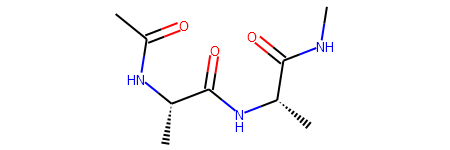

In [7]:
# Define SMILES by either using OpenBabel
# folder = '/home/nutt/AA/'
# xyzname = 'AA_struct-3640_UFFmin_phi_135.003080083_psi_134.998144891.xyz'
# xyzpath = folder + xyzname
# xyz2sml = os.popen('obabel ' + xyzpath + ' -o smiles').read()
# sml = xyz2sml.split()[0]

# or manually define SMILES
sml = 'CC(=O)N[C@@H](C)C(=O)N[C@@H](C)C(=O)NC'  ## alanine tripeptide
mol = Chem.MolFromSmiles(sml)
mol = Chem.RemoveHs(mol)
# DrawingOptions.includeAtomNumbers = True

mol

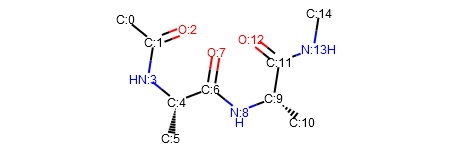

In [8]:
mol_idx = mol_with_atom_index(mol)
mol_idx

### List of all four atoms defining all dihedral angle for backbone

In [9]:
torsionList = enumerateTorsions(mol)
torsionList

[(0, 1, 3, 4),
 (2, 1, 3, 4),
 (1, 3, 4, 5),
 (1, 3, 4, 6),
 (3, 4, 6, 7),
 (3, 4, 6, 8),
 (5, 4, 6, 7),
 (5, 4, 6, 8),
 (4, 6, 8, 9),
 (7, 6, 8, 9),
 (6, 8, 9, 10),
 (6, 8, 9, 11),
 (8, 9, 11, 12),
 (8, 9, 11, 13),
 (10, 9, 11, 12),
 (10, 9, 11, 13),
 (9, 11, 13, 14),
 (12, 11, 13, 14)]

### List of all four atoms defining Phi & Psi dihedral angles around alpha carbon 

In [10]:
# Phi-Psi dihedral angles around alpha carbon
phipsiList = [(1, 3, 4 ,5),
              (3, 4, 5, 6),
              (6, 8, 9, 11),
              (8, 9, 11, 13)]

# Prepare the features

In [11]:
# set dih_list to phiphilist or torsionList
dih_list = torsionList
# dih_list = phipsiList

# Compute cosine and sine of each dihedral angles
dih_cos = np.zeros((R.shape[0], len(dih_list)))   
dih_sin = np.zeros((R.shape[0], len(dih_list)))   
for i in range(R.shape[0]):
    for j, t in enumerate(dih_list):
        dih_angle = cal_dihedral(R[i][t[0]], R[i][t[1]], R[i][t[2]], R[i][t[3]])
        dih_cos[i][j] = np.cos(dih_angle *np.pi / 180.0)
        dih_sin[i][j] = np.sin(dih_angle *np.pi / 180.0)

# Assemble a feature array

In [12]:
# Reshape and transpose energy matrix from 1D array to 2D array so that it can be combined with other features
E_re = np.reshape(E, (-1, 1))

# Calculate the matrix norm of forces for each conformer
F_norm = np.linalg.norm(F, axis=(1,2))
F_norm_re = np.reshape(F_norm, (-1, 1))

# Combine cosine and sin together
data = np.concatenate((dih_cos, 
                       dih_sin, 
                       E_re, 
#                        F_norm_re
                      ), axis=1)
data.shape

(1750, 37)

In [13]:
# Create a dataframe
# head = ['cos_' + str(i+1) for i in range(dih_cos.shape[1])] + ['sin_' + str(i+1) for i in range(dih_sin.shape[1])]
head = ['cos_' + str(i+1) for i in range(dih_cos.shape[1])] + ['sin_' + str(i+1) for i in range(dih_sin.shape[1])] + ['E']
# head = ['cos_' + str(i+1) for i in range(dih_cos.shape[1])] + ['sin_' + str(i+1) for i in range(dih_sin.shape[1])] + ['E', 'F']

df_data = pd.DataFrame(data, columns=head)

df_data

,cos_1,cos_2,cos_3,cos_4,cos_5,cos_6,cos_7,cos_8,cos_9,cos_10,...,sin_10,sin_11,sin_12,sin_13,sin_14,sin_15,sin_16,sin_17,sin_18,E
0,0.991586,-0.992243,-0.012931,-0.812064,0.662578,-0.707092,-0.986622,0.974821,-0.884919,0.854404,...,-0.519610,-0.592144,1.000000,-0.904362,0.906760,0.883483,-0.880820,-0.000255,-0.005418,-465463.793815
1,0.991461,-0.992388,-0.016065,-0.806381,0.681271,-0.707916,-0.985731,0.978820,-0.897229,0.879918,...,-0.475125,-0.578173,0.999906,-0.907942,0.909006,0.881520,-0.880314,0.002523,-0.005038,-465484.713688
2,0.991246,-0.993036,-0.022448,-0.791888,0.707178,-0.705806,-0.982735,0.983092,-0.935251,0.935960,...,-0.352106,-0.565321,0.999741,-0.908341,0.906132,0.881556,-0.884024,0.012564,-0.007356,-465489.901713
3,0.992157,-0.993996,-0.030467,-0.778387,0.713547,-0.710148,-0.982656,0.983542,-0.978408,0.979445,...,-0.201714,-0.571056,0.999916,-0.904820,0.899929,0.886790,-0.891979,0.027250,-0.015904,-465491.978811
4,0.994028,-0.995869,-0.052382,-0.755284,0.706086,-0.734785,-0.986238,0.978552,-0.999030,0.996126,...,-0.087942,-0.620149,0.998445,-0.892650,0.887494,0.901857,-0.906687,0.037711,-0.026297,-465492.839347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,0.999912,-0.999962,-0.930497,0.178547,-0.981672,0.973347,0.360344,-0.323086,-0.999889,0.998424,...,-0.056126,-0.899017,0.893424,-0.421503,0.477930,-0.458612,0.401577,0.095523,-0.031278,-465500.276779
1746,0.999954,-0.999979,-0.931163,0.180420,-0.981308,0.972546,0.358592,-0.319825,-0.999853,0.998198,...,-0.060006,-0.895674,0.896648,-0.419042,0.475276,-0.461396,0.404726,0.095991,-0.032032,-465500.259946
1747,0.999982,-0.999988,-0.932747,0.184525,-0.980718,0.971584,0.355514,-0.315701,-0.999775,0.997875,...,-0.065154,-0.892146,0.900146,-0.413140,0.469293,-0.466707,0.410472,0.096946,-0.033280,-465500.251886
1748,0.999991,-0.999994,-0.934546,0.188853,-0.980332,0.970873,0.353196,-0.312381,-0.999763,0.997766,...,-0.066808,-0.891488,0.900723,-0.412635,0.468810,-0.467066,0.410837,0.095821,-0.032149,-465500.253880


# Data preprocessing

In [14]:
# Standardize the data using fit_transform
data_std = StandardScaler().fit_transform(data)

# Dimensionality reduction

### Run PCA with all features to determine the number of components contributing to >= 80% variance

In [15]:
# Fit our standardized data using PCA
pca = PCA(n_components=data_std.shape[1])
pca.fit(data_std)

# Then, we need to decide the number of components we’d like to keep based on the cumulative variance plot
variance = pca.explained_variance_ratio_

var = np.cumsum(np.round(variance, decimals=3)*100)
var #cumulative sum of variance explained with [n] components

array([ 21. ,  37.7,  49.2,  60.1,  68.8,  75.7,  81.7,  86.6,  90.5,
        93. ,  95.2,  97.2,  98.2,  99.2,  99.7,  99.8,  99.9, 100. ,
       100. , 100. , 100. , 100. , 100. , 100. , 100. , 100. , 100. ,
       100. , 100. , 100. , 100. , 100. , 100. , 100. , 100. , 100. ,
       100. ])

### Choose number of components

In [16]:
var_80 = int(np.where((var > 80) & (var < 100))[0][-1])
n_comp_var_80 = var_80 + 1

# print(var[var < 100])

print("Chosen number of components =", n_comp_var_80)

Chosen number of components = 17


<IPython.core.display.Javascript object>


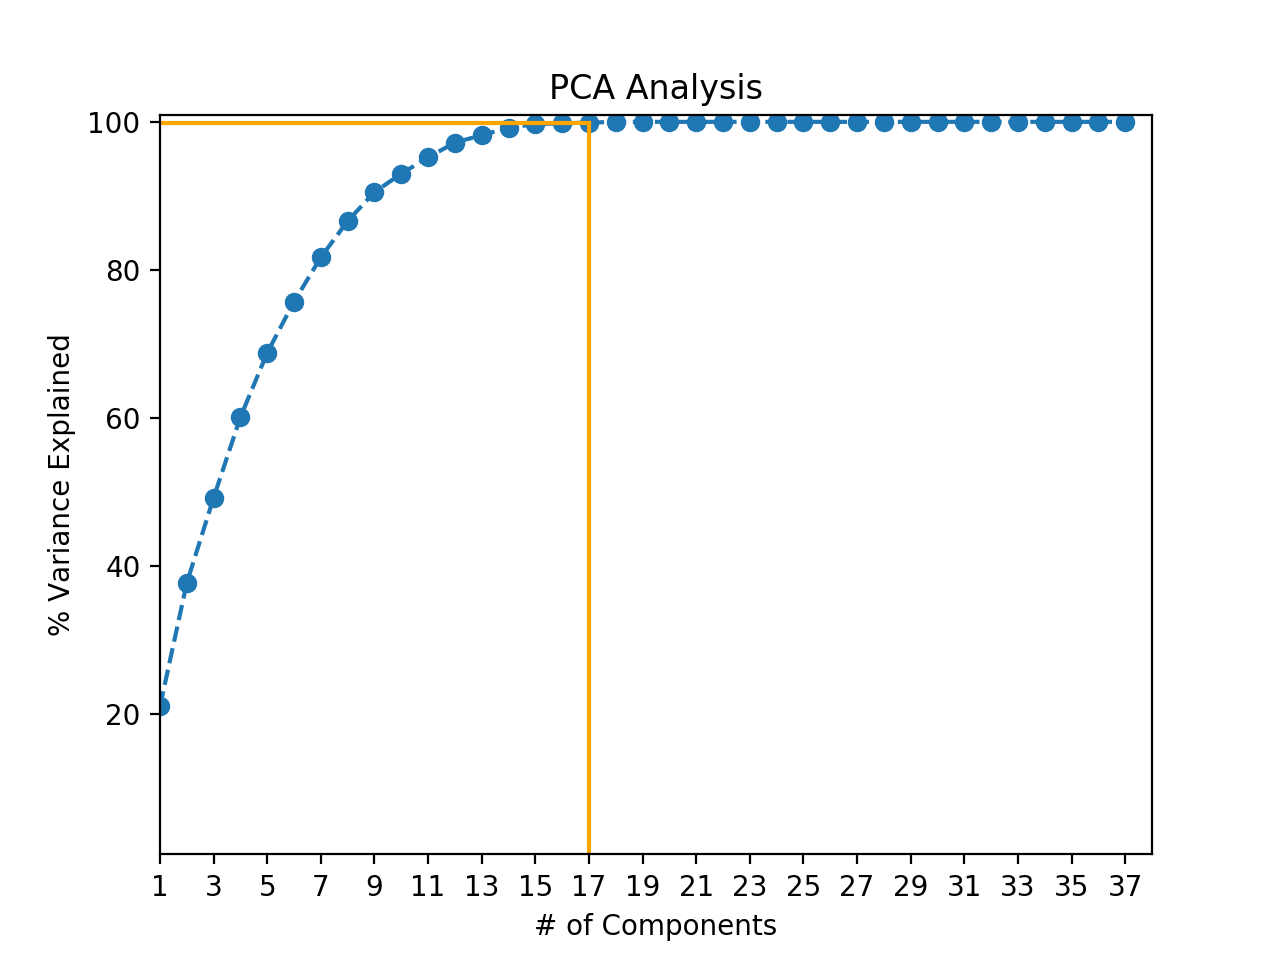

In [17]:
# Plot explained variance with number of components
x_ticks = range(1, var.shape[0]+1, 2)
x_axis = range(1, var.shape[0]+1)

plt.figure()
plt.ylabel('% Variance Explained')
plt.xlabel('# of Components')
plt.title('PCA Analysis')
plt.xlim(1, var.shape[0]+1)
plt.ylim(1,100.9)
plt.xticks(x_ticks)
plt.style.context('seaborn-whitegrid')
plt.plot(x_axis, var, marker='o', linestyle='--')
plt.plot([x_axis[var_80], x_axis[var_80]], [0, var[var_80]], color='orange')
plt.plot([1, x_axis[var_80]], [var[var_80], var[var_80]], color='orange')

### Run PCA again with chosen number of components

In [18]:
pca = PCA(n_components = n_comp_var_80)
# pca = PCA(n_components = 10) # manually choose number of components

data_pca = pca.fit_transform(data_std)
# true = data_pca[:,0] > 20
# np.where(true==True)

pd.DataFrame(data_pca)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,2.426092,-2.961526,6.539461,0.022243,-1.987416,3.855429,6.527970,6.437917,2.606915,-0.886325,-2.913785,-1.109098,-0.754942,1.215452,-0.270729,-0.481121,1.068283
1,2.102285,-2.611009,5.259769,-0.262970,-1.667623,2.154888,5.089022,5.693657,1.671004,-0.722252,-2.610660,-0.463191,-1.040717,-1.401000,-0.385448,-0.553305,0.729888
2,1.856748,-2.235683,3.730803,-0.778982,-2.052973,0.594315,3.059853,3.489329,0.994127,-0.120426,-1.622259,-0.677603,-1.610163,-1.121170,-0.195200,-0.232430,0.161384
3,1.578109,-1.781364,2.294014,-1.202879,-2.631896,-0.447345,1.238238,1.144246,0.641882,0.478312,-0.480829,-0.813256,-1.988457,-0.510965,0.113511,-0.087584,0.132400
4,1.313036,-1.345397,1.480451,-1.389505,-3.004607,-0.501351,0.375879,-0.288552,0.748634,0.731294,0.359247,-0.618288,-2.026212,-0.307428,0.251524,-0.144927,0.389238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,3.932856,3.648662,-1.025931,1.752648,-0.434354,-0.617408,-0.196304,0.391038,-1.320545,-0.497588,1.204156,-0.726245,0.871883,-0.077720,-0.051958,-0.148290,0.016579
1746,3.935258,3.657991,-1.026888,1.740307,-0.425868,-0.609601,-0.165585,0.402854,-1.353655,-0.487517,1.182441,-0.734539,0.869531,-0.074880,-0.046169,-0.156705,0.025801
1747,3.938515,3.671973,-1.032955,1.722144,-0.412392,-0.604991,-0.126201,0.437232,-1.397337,-0.471909,1.164227,-0.748210,0.872534,-0.070615,-0.035697,-0.166271,0.034247
1748,3.942880,3.684160,-1.029340,1.707063,-0.399607,-0.603568,-0.124130,0.440500,-1.397517,-0.476489,1.138430,-0.746027,0.869719,-0.068913,-0.024664,-0.166783,0.039635


In [19]:
# Choose what data will be used to color the scatterplot
## Normalizaed energy
color = (E - np.min(E))/(np.max(E) - np.min(E))
color_label = 'Normalized Energy'

## Standardized energy
# color = (E - np.mean(E))/np.std(E)
# color_label = 'Standardized Energy'

<IPython.core.display.Javascript object>


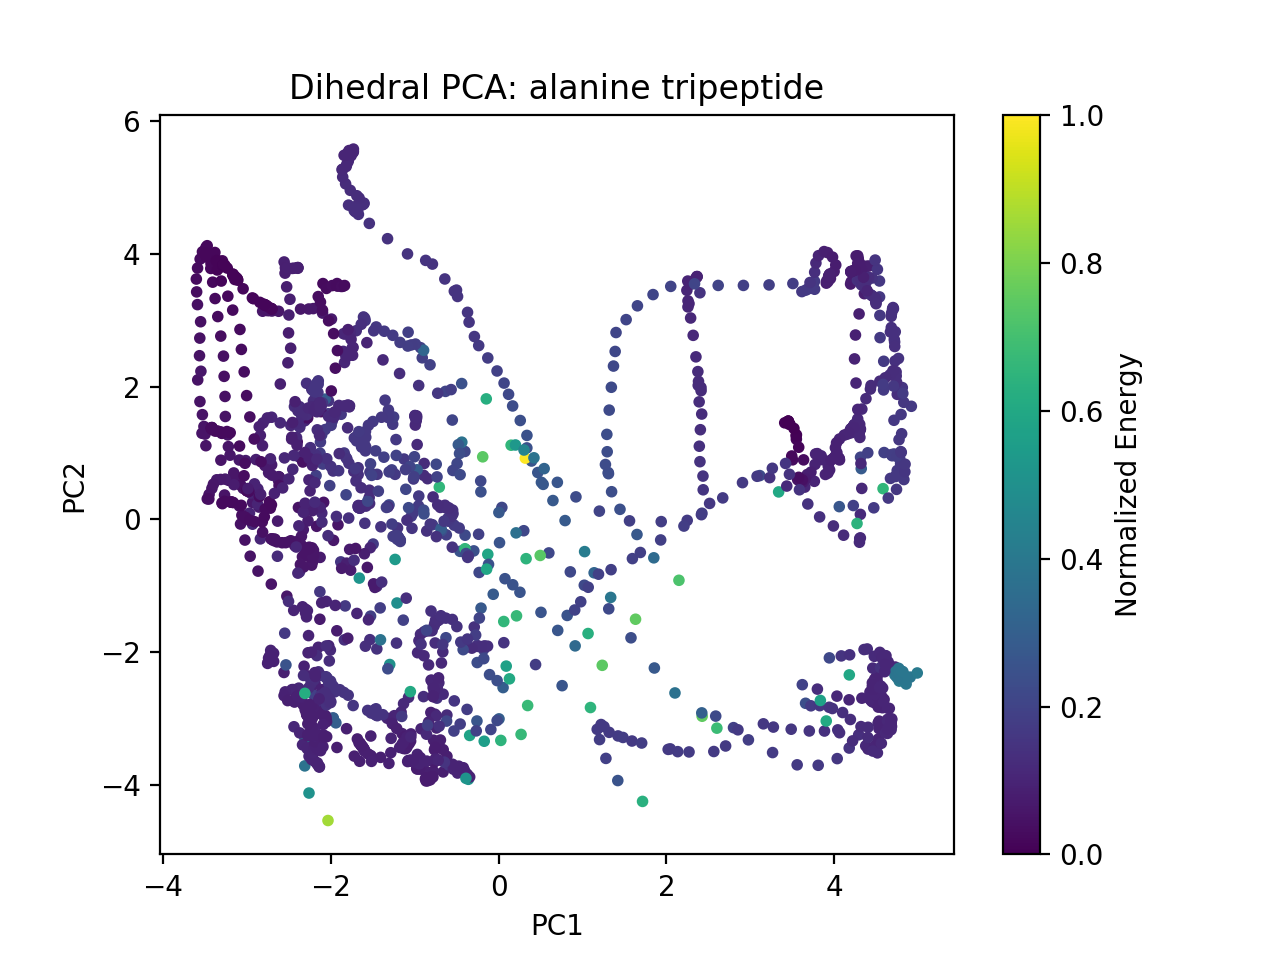

In [20]:
# 2 components plot
traj_id = np.arange(1, data_pca.shape[0]+1)

plt.figure()
plt.scatter(data_pca[:, 0], 
            data_pca[:, 1], 
            c=color, marker='o', s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
# plt.xlim(-5, 10)
# plt.ylim(0, 10)
plt.title('Dihedral PCA: alanine tripeptide')
cbar = plt.colorbar()
cbar.set_label(color_label)

<IPython.core.display.Javascript object>


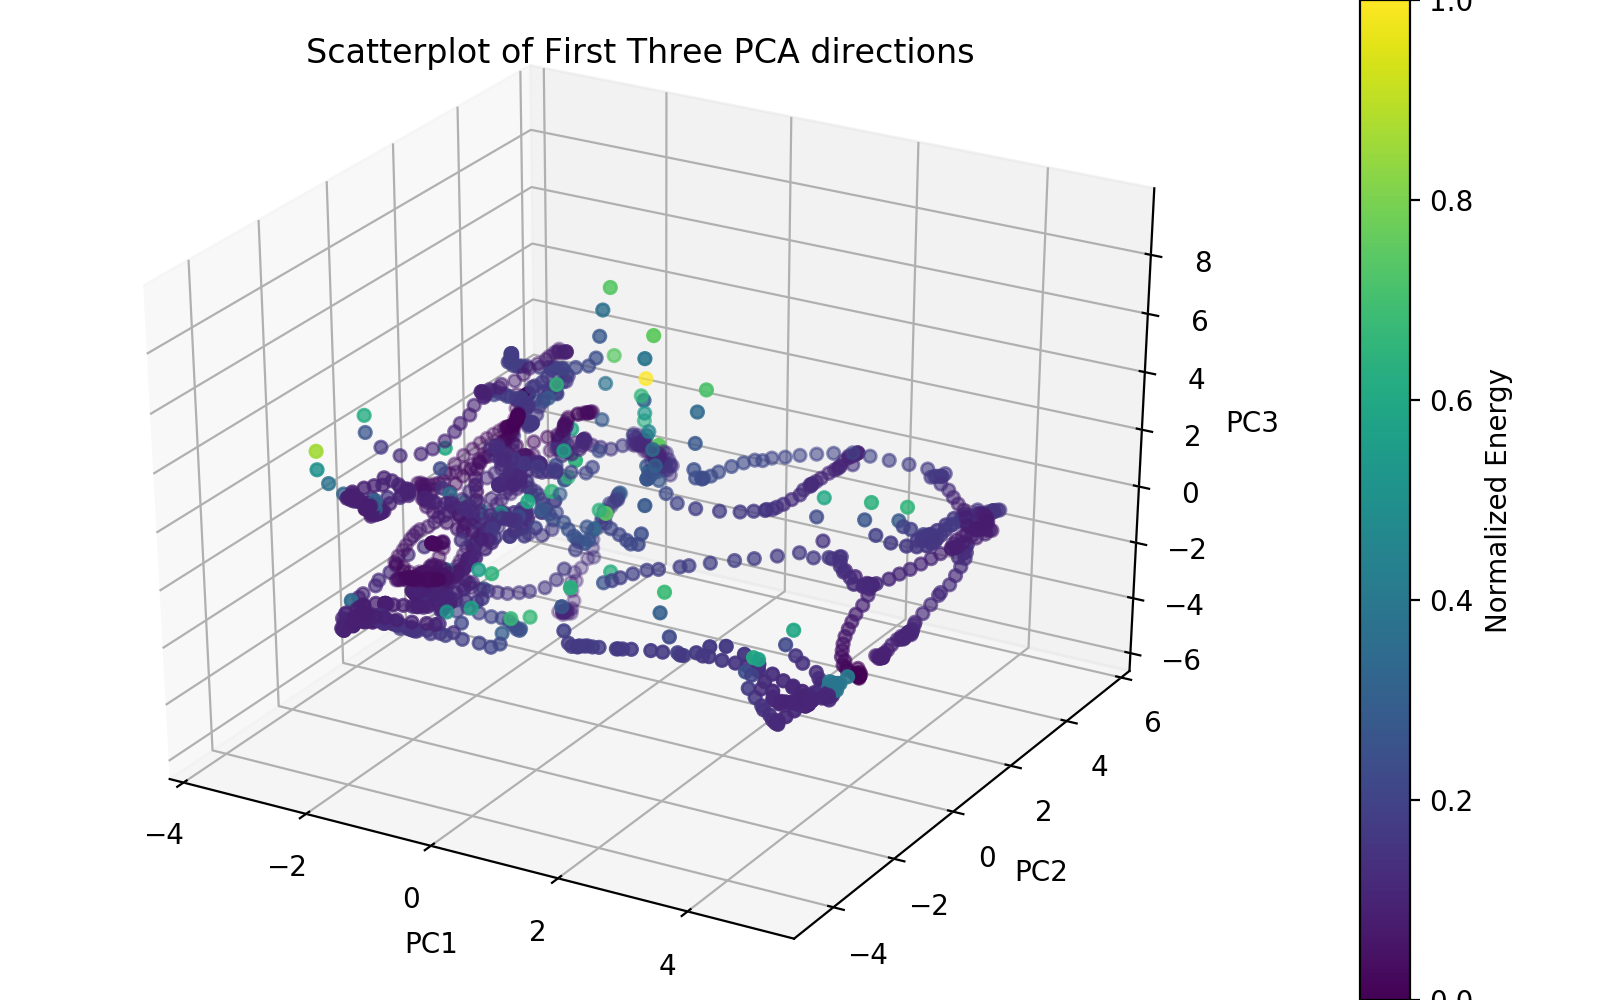

In [21]:
# 3 components plot
traj_id = np.arange(1, data_pca.shape[0]+1)

fig = plt.figure(figsize=(8,5))
ax = Axes3D(fig)
p = ax.scatter(data_pca[:,0], 
               data_pca[:,1], 
               data_pca[:,2], 
               c=color, marker='o', s=20)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('Scatterplot of First Three PCA directions')
cbar = fig.colorbar(p)
cbar.set_label(color_label)

<IPython.core.display.Javascript object>


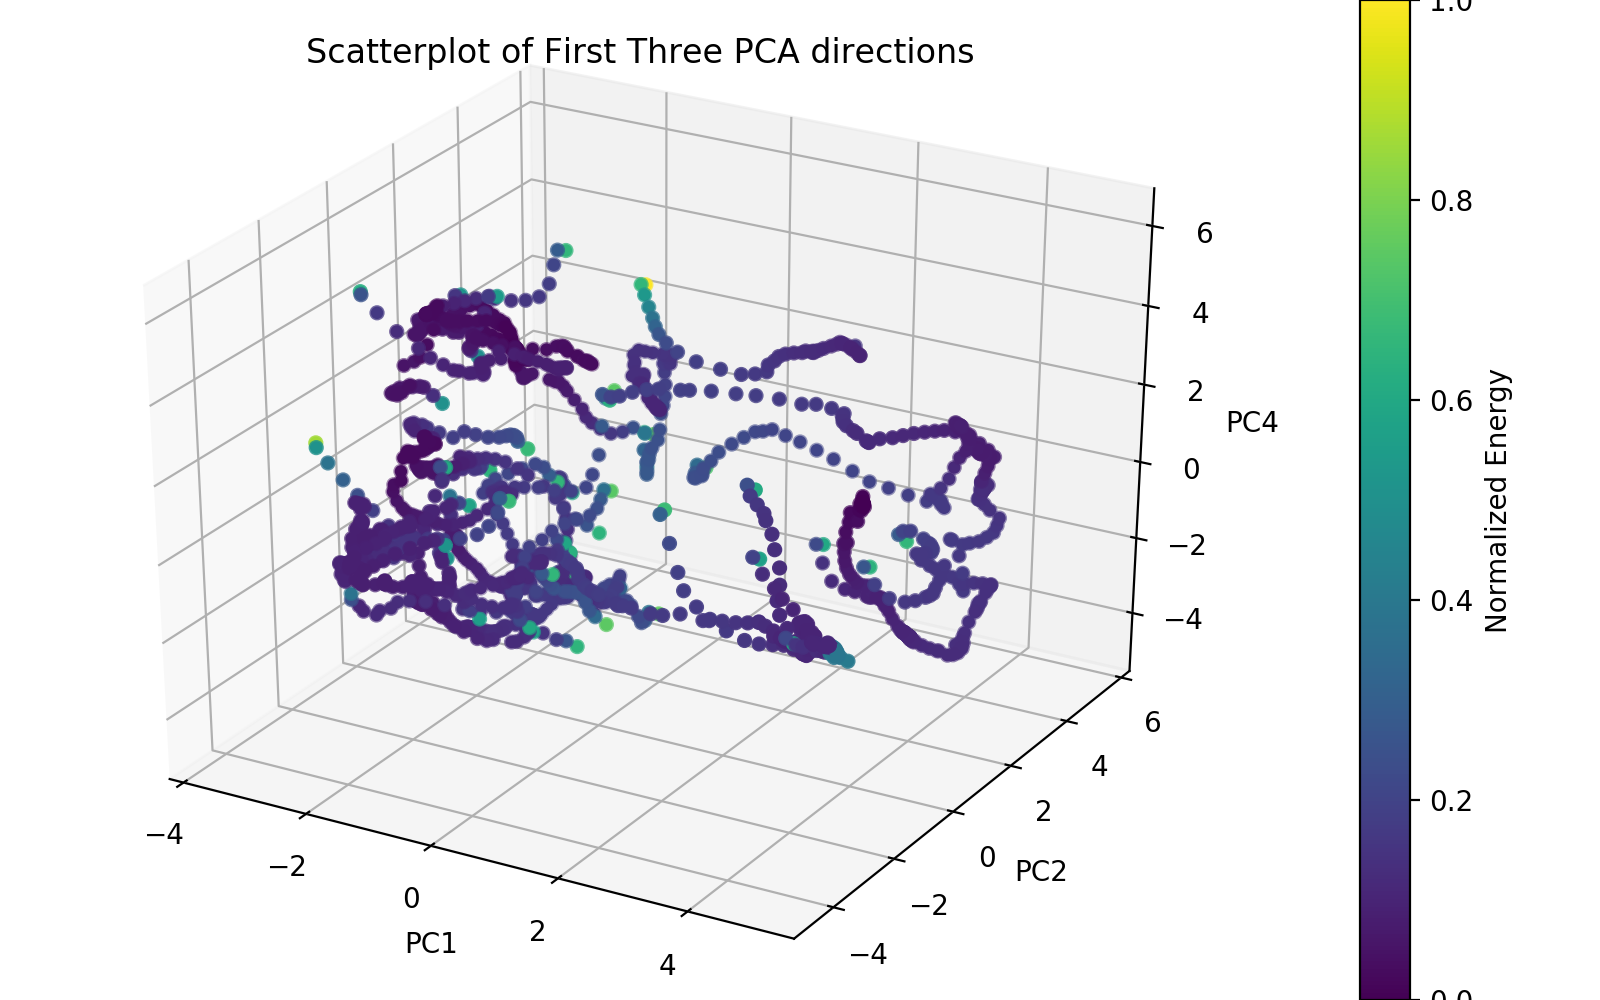

In [22]:
# 3 components plot
traj_id = np.arange(1, data_pca.shape[0]+1)

fig = plt.figure(figsize=(8,5))
ax = Axes3D(fig)
p = ax.scatter(data_pca[:,0], 
               data_pca[:,1], 
               data_pca[:,3], 
               c=color, marker='o', s=20)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC4')
plt.title('Scatterplot of First Three PCA directions')
cbar = fig.colorbar(p)
cbar.set_label(color_label)

<IPython.core.display.Javascript object>


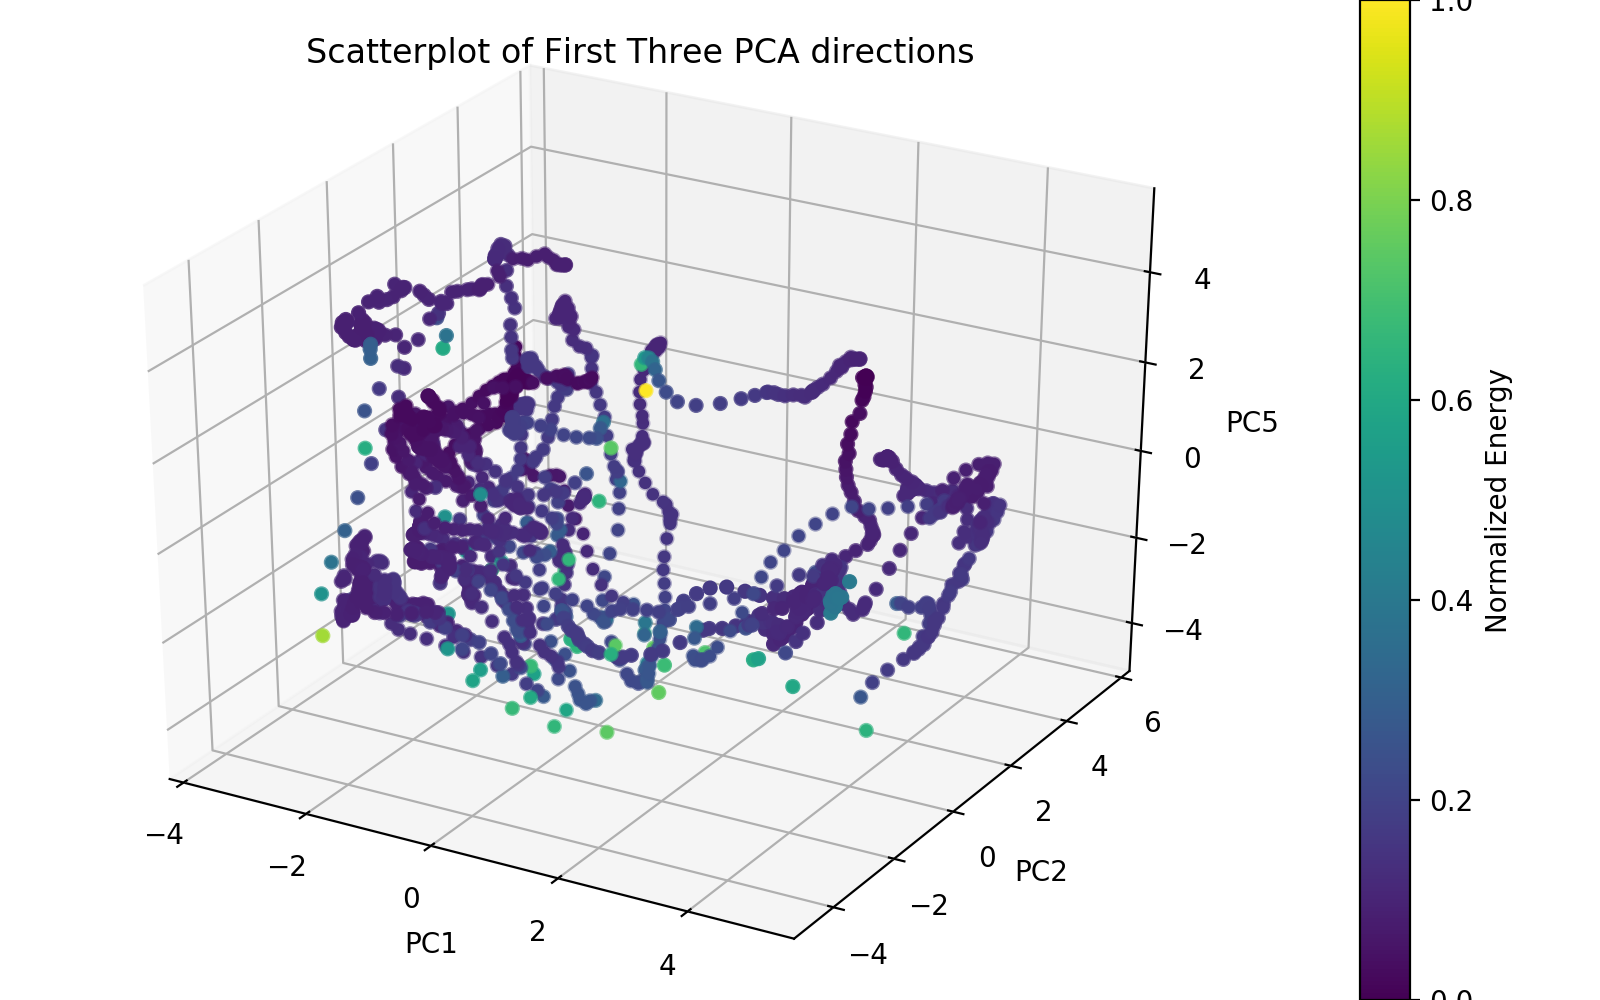

In [23]:
# 3 components plot
traj_id = np.arange(1, data_pca.shape[0]+1)

fig = plt.figure(figsize=(8,5))
ax = Axes3D(fig)
p = ax.scatter(data_pca[:,0], 
               data_pca[:,1], 
               data_pca[:,4], 
               c=color, marker='o', s=20)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC5')
plt.title('Scatterplot of First Three PCA directions')
cbar = fig.colorbar(p)
cbar.set_label(color_label)

# K-means clustering with PCA

### Determine the optimal number of clusters

In [24]:
# Calculate within cluster sum of squares error (wcss)
wcss = []
for i in range(1, 41):
    kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_pca = kmeans_pca.fit(data_pca)
    wcss.append(kmeans_pca.inertia_)

<IPython.core.display.Javascript object>


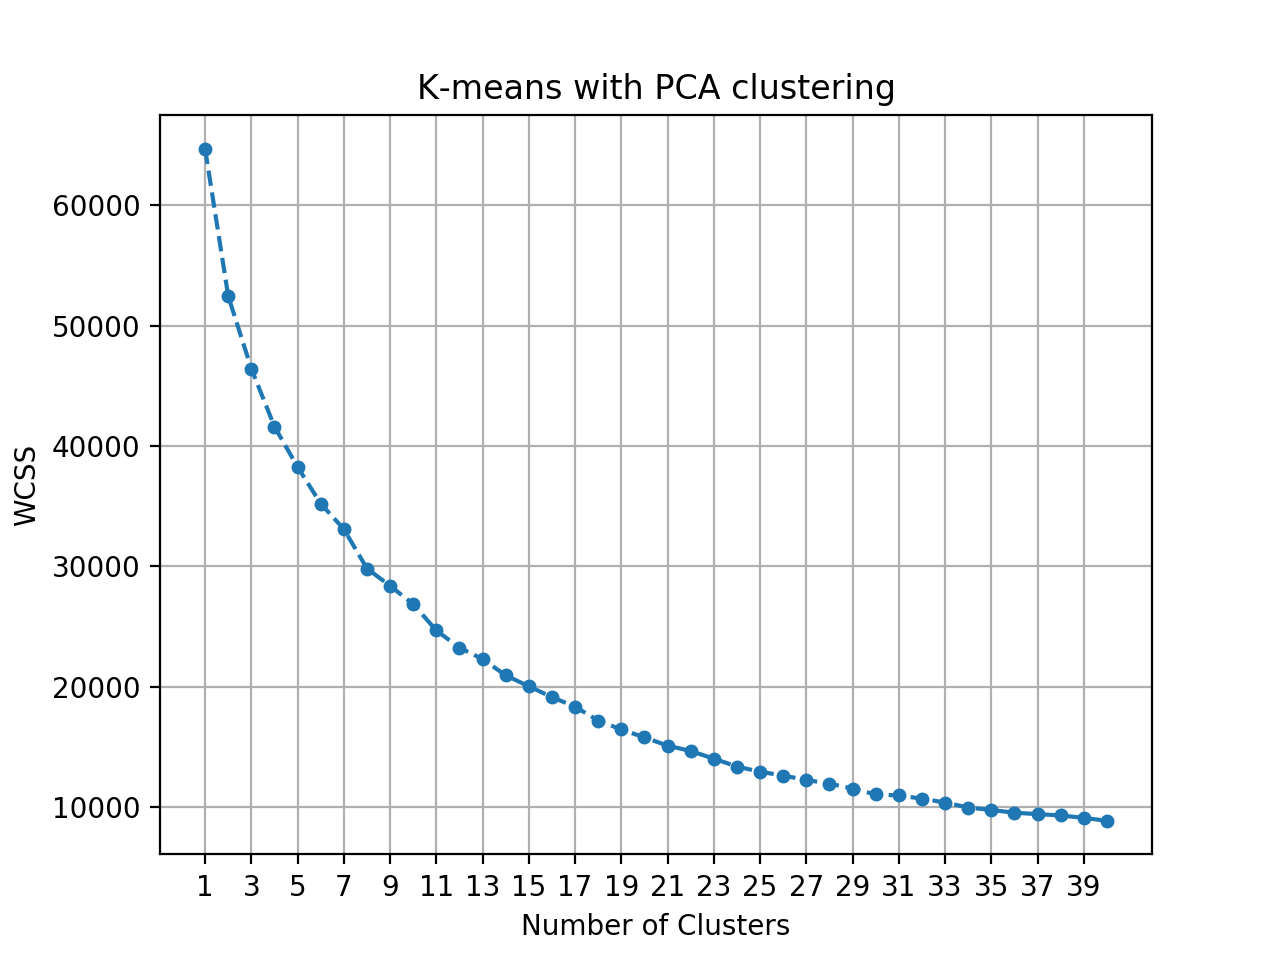

In [25]:
plt.figure()
plt.plot(range(1, 41), wcss, marker='o', linestyle='--', markersize=4)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 41, 2))
plt.title('K-means with PCA clustering')
plt.grid()

We now have to choose the k (number of clusters) for which WSS becomes first starts to diminish. In the plot of WSS-versus-k, this is visible as an elbow and it looks like that it has an elbow at *chosen_num_cluster*

In [26]:
chosen_num_cluster = 14

### Perform K-means with a chosen number of clusters

In [27]:
kmeans_pca = KMeans(n_clusters=chosen_num_cluster, init='k-means++', random_state=42)
kmeans_pca.fit(data_pca)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=14, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=42, tol=0.0001, verbose=0)

In [28]:
# Combine two dataframes into one dataframe
df_data_pca_kmeans = pd.concat([df_data.reset_index(drop=True), pd.DataFrame(data_pca)], axis = 1)
# Set column name
df_data_pca_kmeans.columns.values[-n_comp_var_80: ] = ['Component_' + str(i + 1) for i in range(n_comp_var_80)] 
df_data_pca_kmeans['K-means PCA'] = kmeans_pca.labels_

# The last column of new dataframe ('K-means PCA') contains cluster index that each geometry belongs to
df_data_pca_kmeans.head()

,cos_1,cos_2,cos_3,cos_4,cos_5,cos_6,cos_7,cos_8,cos_9,cos_10,...,Component_9,Component_10,Component_11,Component_12,Component_13,Component_14,Component_15,Component_16,Component_17,K-means PCA
0,0.991586,-0.992243,-0.012931,-0.812064,0.662578,-0.707092,-0.986622,0.974821,-0.884919,0.854404,...,2.606915,-0.886325,-2.913785,-1.109098,-0.754942,1.215452,-0.270729,-0.481121,1.068283,10
1,0.991461,-0.992388,-0.016065,-0.806381,0.681271,-0.707916,-0.985731,0.978820,-0.897229,0.879918,...,1.671004,-0.722252,-2.610660,-0.463191,-1.040717,-1.401000,-0.385448,-0.553305,0.729888,10
2,0.991246,-0.993036,-0.022448,-0.791888,0.707178,-0.705806,-0.982735,0.983092,-0.935251,0.935960,...,0.994127,-0.120426,-1.622259,-0.677603,-1.610163,-1.121170,-0.195200,-0.232430,0.161384,10
3,0.992157,-0.993996,-0.030467,-0.778387,0.713547,-0.710148,-0.982656,0.983542,-0.978408,0.979445,...,0.641882,0.478312,-0.480829,-0.813256,-1.988457,-0.510965,0.113511,-0.087584,0.132400,4
4,0.994028,-0.995869,-0.052382,-0.755284,0.706086,-0.734785,-0.986238,0.978552,-0.999030,0.996126,...,0.748634,0.731294,0.359247,-0.618288,-2.026212,-0.307428,0.251524,-0.144927,0.389238,4


In [29]:
# Add name of the segment of each geometry to cluster label
df_data_pca_kmeans['Segment'] = df_data_pca_kmeans['K-means PCA'].map(
    {i:'cluster_' + str(i + 1) + '_' for i in range(kmeans_pca.n_clusters)})

df_data_pca_kmeans[['Segment']]

,Segment
0,cluster_11_
1,cluster_11_
2,cluster_11_
3,cluster_5_
4,cluster_5_
...,...
1745,cluster_9_
1746,cluster_9_
1747,cluster_9_
1748,cluster_9_


# Visualization of K-Means + PCA clustering

In [30]:
# Get all geometries in dataframe containing given cluster_N_
df = df_data_pca_kmeans

df_clusters = []
for i in range(chosen_num_cluster):
    df_clusters.append(df[df['Segment'].str.match(f"cluster_{i + 1}_")])

# For example, show the dataframe of all geometries that are in cluster_1_
df_clusters[0].head()

,cos_1,cos_2,cos_3,cos_4,cos_5,cos_6,cos_7,cos_8,cos_9,cos_10,...,Component_10,Component_11,Component_12,Component_13,Component_14,Component_15,Component_16,Component_17,K-means PCA,Segment
485,0.955261,-0.966170,-0.989022,0.383530,0.946561,-0.955652,-0.214571,0.243254,-0.999123,0.999930,...,-1.138994,-1.066960,-0.503451,0.165031,-0.012673,0.310744,0.049184,-0.167989,0,cluster_1_
486,0.953110,-0.964491,-0.995807,0.423402,0.908795,-0.920932,-0.101969,0.131839,-0.999062,0.999918,...,-1.295905,-1.000129,-0.569922,0.203129,-0.017154,0.452992,0.047355,-0.184734,0,cluster_1_
487,0.958808,-0.967148,-0.995627,0.417710,0.890183,-0.903780,-0.055277,0.085972,-0.998718,0.999814,...,-1.402272,-0.942828,-0.626750,0.223717,-0.047416,0.412906,0.148270,-0.150136,0,cluster_1_
488,0.961543,-0.969100,-0.994185,0.408262,0.893797,-0.905926,-0.063744,0.091479,-0.998977,0.999858,...,-1.410335,-0.928889,-0.625960,0.231725,-0.053420,0.372098,0.156031,-0.125808,0,cluster_1_
489,0.966466,-0.972495,-0.992895,0.399683,0.894012,-0.906968,-0.064976,0.094688,-0.998727,0.999799,...,-1.464015,-0.970418,-0.650284,0.228674,-0.067826,0.320616,0.165991,-0.131024,0,cluster_1_


<IPython.core.display.Javascript object>


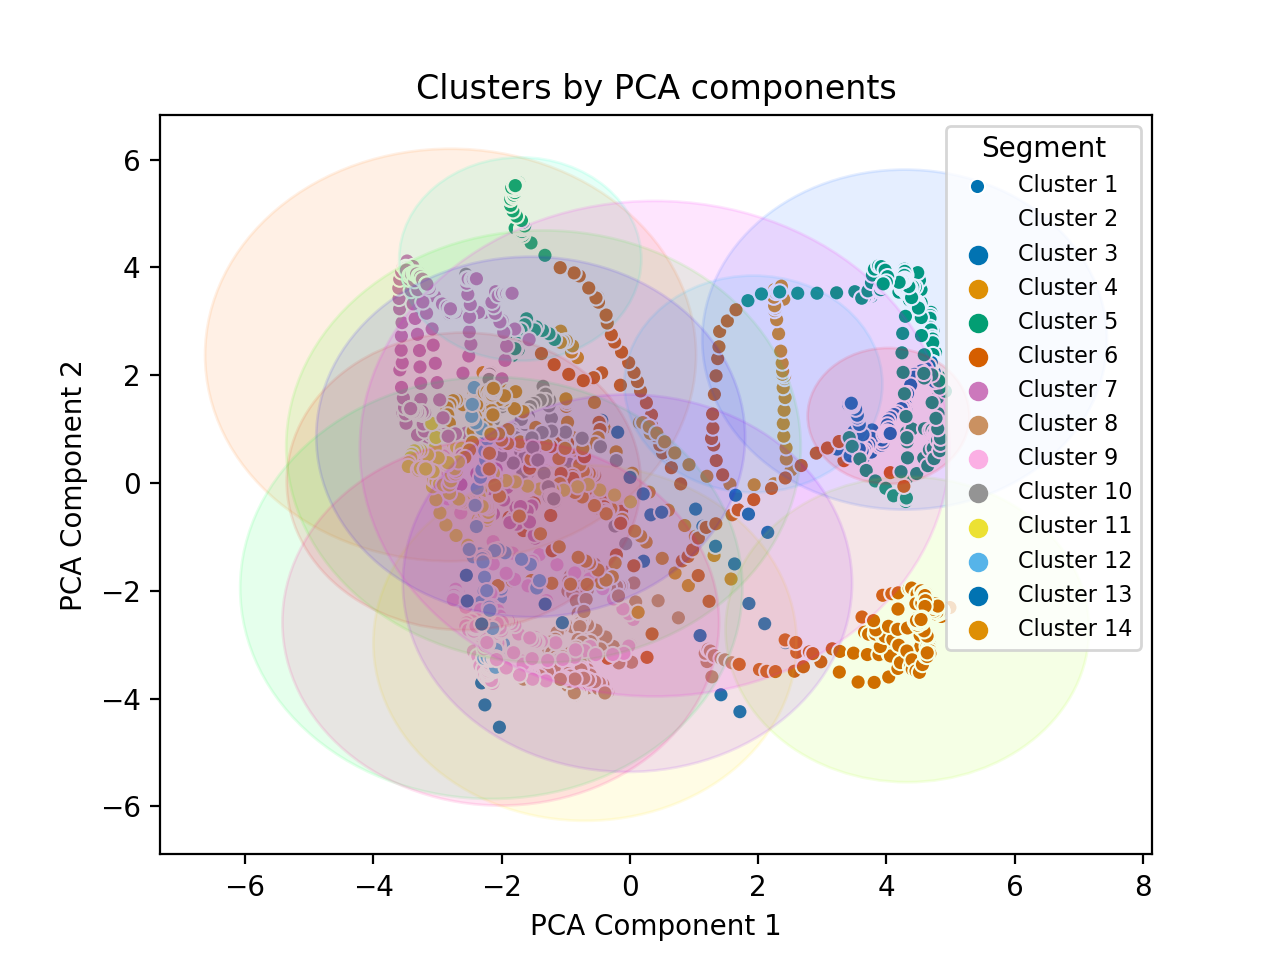

In [31]:
# Visualize the segment with respect to the first two components
import matplotlib.pyplot as plt
import numpy as np; np.random.seed(1)
from scipy.spatial import ConvexHull

x_axis = df_data_pca_kmeans['Component_1']
y_axis = df_data_pca_kmeans['Component_2']

# Scatterplot
# plt.figure(figsize=(8,4.8))
plt.figure()
s = sns.scatterplot(x_axis, y_axis, hue=df_data_pca_kmeans['Segment'], s=30, palette='colorblind')
s.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
# plt.xlim(-3, 14)
plt.legend(title='Segment', labels=['Cluster ' + str(i + 1) for i in range(kmeans_pca.n_clusters)],
          markerscale=1, fontsize=8, loc='upper right')
plt.title('Clusters by PCA components')

# Encircle
def encircle2(x,y, ax=None, **kw):
    if not ax: ax=plt.gca()
    p = np.c_[x,y]
    mean = np.mean(p, axis=0)
    d = p-mean
    r = np.max(np.sqrt(d[:,0]**2+d[:,1]**2 ))
    circ = plt.Circle(mean, radius=1.05*r,**kw)
    ax.add_patch(circ)


def get_cmap(n, name='hsv'):
    """
    Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.
    """
    return plt.cm.get_cmap(name, n)

cmap = get_cmap(chosen_num_cluster)
for i in range(len(df_clusters)):
    encircle2(df_clusters[i]['Component_1'], 
              df_clusters[i]['Component_2'], 
              ec=cmap(i), fc=cmap(i), alpha=0.1)

plt.gca().relim()
plt.gca().autoscale_view()

---

# Spectral clustering with PCA

The method to contruct affinity matrix can be controled using **affinity** argument.
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

### Radial basis function (RBF)

In [43]:
# Building the clustering model 
spectral_model_rbf = SpectralClustering(n_clusters = 25, affinity ='rbf', assign_labels='kmeans') 

# spectral_model_rbf.affinity_matrix_.shape

# Training the model and Storing the predicted cluster labels 
labels_rbf = spectral_model_rbf.fit_predict(data_pca)
labels_rbf

array([ 8,  8,  7, ..., 24, 24, 24])

<IPython.core.display.Javascript object>


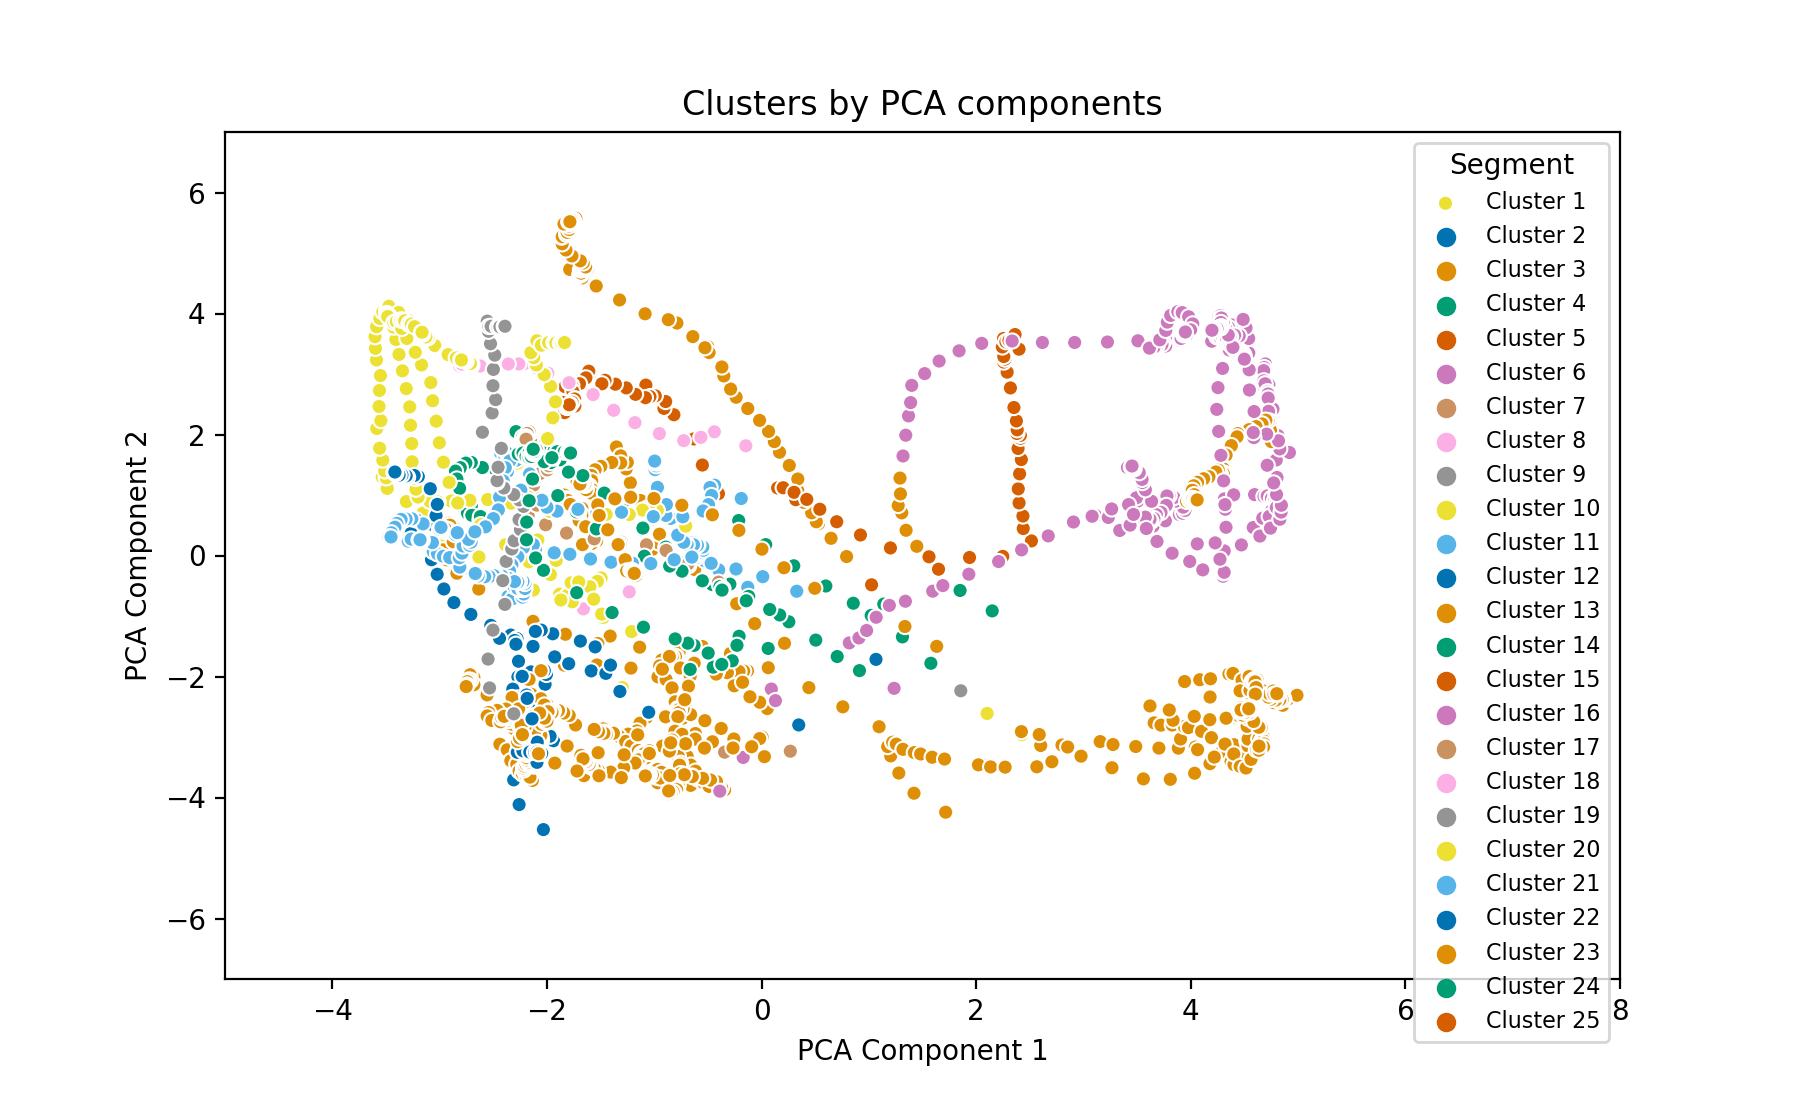

In [46]:
# Visualize the segment with respect to the first two components
import matplotlib.pyplot as plt
import numpy as np; np.random.seed(1)
from scipy.spatial import ConvexHull

x_axis = df_data_pca_kmeans['Component_1']
y_axis = df_data_pca_kmeans['Component_2']

# Scatterplot
plt.figure(figsize=(9,5.5))
s = sns.scatterplot(x_axis, y_axis, hue=labels_rbf, s=30, palette='colorblind')
s.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.xlim(-5, 8)
plt.ylim(-7, 7)
plt.legend(title='Segment', labels=['Cluster ' + str(i + 1) for i in range(spectral_model_rbf.n_clusters)],
          markerscale=1, fontsize=8, loc='upper right')
plt.title('Clusters by PCA components')

# Encircle
def encircle2(x,y, ax=None, **kw):
    if not ax: ax=plt.gca()
    p = np.c_[x,y]
    mean = np.mean(p, axis=0)
    d = p-mean
    r = np.max(np.sqrt(d[:,0]**2+d[:,1]**2 ))
    circ = plt.Circle(mean, radius=1.05*r,**kw)
    ax.add_patch(circ)


# def get_cmap(n, name='hsv'):
#     """
#     Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
#     RGB color; the keyword argument name must be a standard mpl colormap name.
#     """
#     return plt.cm.get_cmap(name, n)

# cmap = get_cmap(chosen_num_cluster)
# for i in range(len(df_clusters)):
#     encircle2(df_clusters[i]['Component_1'], 
#               df_clusters[i]['Component_2'], 
#               ec=cmap(i), fc=cmap(i), alpha=0.1)

plt.gca().relim()
plt.gca().autoscale_view()